# EML Neural Network — Experiment 02
**Complexity-Accuracy Pareto Frontier**

The EML operator is `eml(x, y) = exp(x) − ln(y)`. Experiment 01 showed the network
finds *some* EML construction — not necessarily the *minimal* one.

Adding a complexity penalty `λ` to the loss:

| Model | Penalty | Effect |
|---|---|---|
| `EMLTree(depth=2)` | `λ · Σ\|leaf − 1\|` | pulls leaves toward EML terminal `1` |
| `EMLNetwork(depth=2)` | `λ · Σ\|weight\|` | pushes linear weights toward 0 (constant leaves) |

**Three parts:**
1. **Part A** — λ sweep for `EMLTree` targeting *e*: how does the formula change?
2. **Part B** — λ sweep for `EMLNetwork` targeting `exp(x)`: Pareto frontier.
3. **Part C** — Binary search for the critical λ where `EMLNetwork` snaps to minimal.

In [1]:
import math
import time

import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from monogate.network import EMLTree, EMLNetwork, fit

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e",
    "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e",
    "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4",
    "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62",
    "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.8,
    "font.family":      "monospace",
    "font.size":        10,
})
ORANGE = "#e8a020"
BLUE   = "#6ab0f5"
GREEN  = "#4ade80"
RED    = "#f87171"
MUTED  = "#4a4d62"
CYAN   = "#67e8f9"

print(f"torch {torch.__version__}  |  CPU only")

torch 2.11.0+cpu  |  CPU only


In [2]:
def best_of_n(model_fn, n=5, **fit_kwargs):
    best_model, best_losses, best_loss = None, [], float('inf')
    for seed in range(n):
        torch.manual_seed(seed)
        model = model_fn()
        losses = fit(model, **fit_kwargs, log_every=0)
        final = losses[-1] if losses else float('inf')
        if final < best_loss:
            best_model, best_losses, best_loss = model, losses, final
    return best_model, best_losses

def leaf_l1(model):
    return sum((p - 1.0).abs().sum().item() for p in model.parameters())

def weight_l1(model):
    return sum(
        p.abs().sum().item()
        for name, p in model.named_parameters()
        if "weight" in name
    )

def is_weight_sparse(model, tol=0.05):
    return all(
        p.abs().max().item() < tol
        for name, p in model.named_parameters()
        if "weight" in name
    )

LAMBDAS = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

---
## Part A — EMLTree: λ sweep targeting *e*

**Penalty:** `λ · Σ|leaf − 1|`

At `λ=0` the network found `eml(eml(0.571, 1.349), eml(1.047, 0.875))` in experiment 01.
As λ grows, leaves are pulled toward 1. At `depth=2`, setting all leaves to 1 gives
`eml(eml(1,1), eml(1,1)) = eml(e, e) = exp(e) − 1 ≈ 14.78` — *not* e.

This reveals that the leaf→1 penalty has the wrong inductive bias for depth=2:
it eventually pushes the model **away** from the target.

In [3]:
t0       = time.perf_counter()
e_target = torch.tensor(math.e)

rows_e = []
print(f"{'lambda':<10} {'|error|':<12} {'leaf_l1':<12} formula")
print("─" * 80)
for lam in LAMBDAS:
    m, _ = best_of_n(
        lambda: EMLTree(depth=2), n=5,
        target=e_target, steps=3000, lr=0.05, lam=lam, loss_threshold=1e-9,
    )
    val   = m().item()
    err   = abs(val - math.e)
    cmplx = leaf_l1(m)
    leaves = [p.item() for p in m.parameters()]
    form  = m.formula()
    rows_e.append({'lam': lam, 'error': err, 'complexity': cmplx,
                   'leaves': leaves, 'formula': form})
    print(f"{lam:<10} {err:<12.3e} {cmplx:<12.4f} {form[:55]}")

print(f"\nPart A wall time: {time.perf_counter()-t0:.1f}s")

lambda     |error|      leaf_l1      formula
────────────────────────────────────────────────────────────────────────────────


0          1.873e-04    0.9489       eml(eml(0.57099, 1.3484), eml(1.0471, 0.87565))


0.001      1.064e-04    0.7888       eml(eml(0.55845, 1.3389), eml(1.0081, 1.0002))


0.005      3.122e-04    0.7289       eml(eml(0.53393, 1.2606), eml(0.99986, 1.0021))


0.01       5.689e-04    0.5620       eml(eml(0.44898, 1.0012), eml(1.0018, 1.008))


0.05       7.240e-03    0.5683       eml(eml(0.44735, 0.99362), eml(1.0003, 1.009))


0.1        8.643e-03    0.5651       eml(eml(0.44855, 0.99578), eml(0.99796, 0.99257))


0.5        4.315e-02    0.5537       eml(eml(0.45892, 1.008), eml(0.99911, 0.99631))


1.0        5.801e-02    0.5445       eml(eml(0.45959, 1.0029), eml(0.99963, 1.0008))


2.0        1.797e-01    0.5585       eml(eml(0.48474, 1.0072), eml(1.0175, 0.98138))

Part A wall time: 66.1s


---
## Part B — EMLNetwork: Pareto frontier for exp(x)

**Penalty:** `λ · Σ|weight|` (L1 on linear leaf weight matrices)

Pushing weights toward 0 makes leaves behave as constants — simpler expressions.
The right leaf for `exp(x) = eml(x, 1)` *should* be constant, so L1 on weights
is the correct inductive bias here.

**Pareto frontier:** x-axis = weight L1 (complexity), y-axis = normalised MSE.

In [4]:
t0     = time.perf_counter()
x2     = torch.linspace(0.1, 3.0, 100).unsqueeze(1)
y2     = torch.exp(x2.squeeze())
x2n    = (x2 - 0.1) / 2.9
y2_max = y2.max().item()
y2n    = y2 / y2_max

rows_exp = []
print(f"{'lambda':<10} {'norm_mse':<14} {'weight_l1':<14} {'sparse?':<10} formula")
print("─" * 90)
for lam in LAMBDAS:
    m, losses = best_of_n(
        lambda: EMLNetwork(in_features=1, depth=2), n=3,
        x=x2n, y=y2n, steps=2000, lr=0.01, lam=lam, loss_threshold=1e-9,
    )
    norm_mse = losses[-1] if losses else float('nan')
    cmplx    = weight_l1(m)
    sparse   = is_weight_sparse(m, tol=0.05)
    form     = m.formula(['x'])
    rows_exp.append({'lam': lam, 'norm_mse': norm_mse, 'complexity': cmplx,
                     'sparse': sparse, 'formula': form})
    tag = 'SPARSE' if sparse else ''
    print(f"{lam:<10} {norm_mse:<14.3e} {cmplx:<14.4f} {tag:<10} {form[:45]}")

print(f"\nPart B wall time: {time.perf_counter()-t0:.1f}s")

lambda     norm_mse       weight_l1      sparse?    formula
──────────────────────────────────────────────────────────────────────────────────────────


0          8.596e-05      2.1888                    eml(eml((0.5557·x+0.1013), (0.1069·x+1.955)),


0.001      1.216e-04      1.2698                    eml(eml((0.5481·x+0.07597), (1.985)), eml((0.


0.005      3.937e-03      0.3704                    eml(eml((0.3562·x+0.1165), (-0.00012·x+1.991)


0.01       4.697e-03      0.2707                    eml(eml((0.2691·x+0.2612), (0.0007372·x+1.947


0.05       6.318e-03      0.1155                    eml(eml((0.1097·x+0.6712), (-0.002438·x+2.081


0.1        6.827e-03      0.0796                    eml(eml((0.07581·x+0.8237), (0.0008087·x+2.27


0.5        1.290e-02      0.0559                    eml(eml((0.05315·x+0.8349), (-0.001013·x+2.20


1.0        6.572e-02      0.0100         SPARSE     eml(eml((0.004076·x+0.3415), (0.004098·x+1.70


2.0        6.611e-02      0.0066         SPARSE     eml(eml((0.0006451·x+0.3409), (-0.002184·x+1.

Part B wall time: 110.4s


---
## Part C — Binary search: critical λ for EMLNetwork

Find the smallest λ where all leaf linear weights drop below 0.05 (effectively
constant leaves = sparse formula). Reports the critical λ and the MSE cost of
choosing the minimal-structure formula over the unconstrained fit.

In [5]:
# Bracket from Part B
lam_lo = max((r['lam'] for r in rows_exp if not r['sparse']), default=0.0)
lam_hi = min((r['lam'] for r in rows_exp if r['sparse']),  default=LAMBDAS[-1])

print(f'Bracket: [{lam_lo}, {lam_hi}]')
if lam_lo >= lam_hi:
    print('No sparse→dense transition in sweep.')
    critical_lam = lam_hi
else:
    for i in range(14):
        lam_mid = (lam_lo + lam_hi) / 2
        torch.manual_seed(0)
        m = EMLNetwork(in_features=1, depth=2)
        fit(m, x=x2n, y=y2n, steps=3000, lr=0.01, lam=lam_mid,
            log_every=0, loss_threshold=1e-9)
        if is_weight_sparse(m, tol=0.05):
            lam_hi = lam_mid
        else:
            lam_lo = lam_mid
    critical_lam = (lam_lo + lam_hi) / 2

# Evaluate at critical lambda
torch.manual_seed(0)
m_crit = EMLNetwork(in_features=1, depth=2)
fit(m_crit, x=x2n, y=y2n, steps=3000, lr=0.01, lam=critical_lam,
    log_every=0, loss_threshold=1e-9)
with torch.no_grad():
    pred_crit = m_crit(x2n).numpy() * y2_max
norm_mse_crit = float(((torch.tensor(pred_crit) - y2)**2).mean()) / y2_max**2
form_crit     = m_crit.formula(['x'])
w_l1_crit     = weight_l1(m_crit)

unconstrained_mse = rows_exp[0]['norm_mse']
mse_cost          = norm_mse_crit - unconstrained_mse

print(f'\n' + '─'*60)
print(f'Critical lambda      : {critical_lam:.6f}')
print(f'Formula              : {form_crit}')
print(f'Weight L1 at crit.   : {w_l1_crit:.4f}')
print(f'Norm MSE at crit.    : {norm_mse_crit:.3e}')
print(f'')
print(f'MSE cost of minimal structure vs unconstrained:')
print(f'  lambda=0 norm MSE   : {unconstrained_mse:.3e}')
print(f'  critical norm MSE   : {norm_mse_crit:.3e}')
print(f'  increase            : {mse_cost/unconstrained_mse*100:.1f}%')

Bracket: [0.5, 1.0]



────────────────────────────────────────────────────────────
Critical lambda      : 0.500015
Formula              : eml(eml((0.03503·x+1.067), (0.002276·x+2.79)), eml((-0.0005063·x+6.44), (0.0001765·x+-0.8192)))
Weight L1 at crit.   : 0.0380
Norm MSE at crit.    : 9.127e-03

MSE cost of minimal structure vs unconstrained:
  lambda=0 norm MSE   : 8.596e-05
  critical norm MSE   : 9.127e-03
  increase            : 10518.4%


Saved → experiment_02_results.png


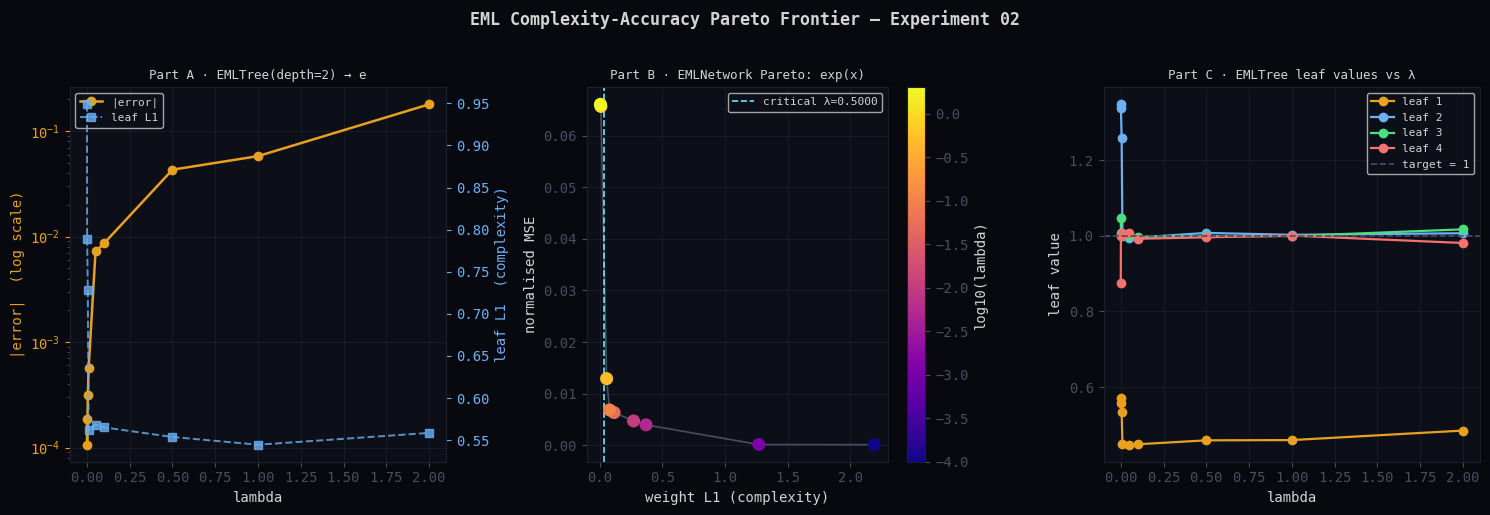

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EML Complexity-Accuracy Pareto Frontier — Experiment 02',
             color='#d4d4d4', fontsize=12, fontweight='bold', y=1.02)

lams_a  = [r['lam'] for r in rows_e]
errs_a  = [r['error'] for r in rows_e]
cmplx_a = [r['complexity'] for r in rows_e]

# Panel A: EMLTree error + leaf_l1 vs lambda
ax  = axes[0]
ax2 = ax.twinx()
ax.semilogy(lams_a, errs_a,  'o-', color=ORANGE, linewidth=1.8, label='|error|')
ax2.plot(lams_a, cmplx_a, 's--', color=BLUE, linewidth=1.4, label='leaf L1', alpha=0.8)
ax.set_xlabel('lambda')
ax.set_ylabel('|error|  (log scale)', color=ORANGE)
ax2.set_ylabel('leaf L1  (complexity)', color=BLUE)
ax.tick_params(axis='y', colors=ORANGE)
ax2.tick_params(axis='y', colors=BLUE)
ax.set_title('Part A · EMLTree(depth=2) → e', color='#d4d4d4', fontsize=9)
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lab1+lab2, fontsize=8)
ax.grid(True)

# Panel B: EMLNetwork Pareto frontier
ax = axes[1]
cmplx_b = [r['complexity'] for r in rows_exp]
mse_b   = [r['norm_mse']   for r in rows_exp]
lams_b  = [r['lam']        for r in rows_exp]
colors  = [math.log10(l + 1e-4) for l in lams_b]
sc = ax.scatter(cmplx_b, mse_b, c=colors, cmap='plasma', s=70, zorder=3)
ax.plot(cmplx_b, mse_b, color=MUTED, linewidth=1.2, zorder=2)
ax.axvline(w_l1_crit, color=CYAN, linestyle='--', linewidth=1.2,
           label=f'critical λ={critical_lam:.4f}')
plt.colorbar(sc, ax=ax, label='log10(lambda)')
ax.set_xlabel('weight L1 (complexity)')
ax.set_ylabel('normalised MSE')
ax.set_title('Part B · EMLNetwork Pareto: exp(x)', color='#d4d4d4', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True)

# Panel C: leaf convergence (EMLTree)
ax = axes[2]
leaf_mat = np.array([r['leaves'] for r in rows_e])
colors4  = [ORANGE, BLUE, GREEN, RED]
for i in range(leaf_mat.shape[1]):
    ax.plot(lams_a, leaf_mat[:, i], 'o-', color=colors4[i],
            label=f'leaf {i+1}', linewidth=1.6)
ax.axhline(1.0, color=MUTED, linestyle='--', linewidth=1.2, label='target = 1')
ax.set_xlabel('lambda')
ax.set_ylabel('leaf value')
ax.set_title('Part C · EMLTree leaf values vs λ', color='#d4d4d4', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
out_path = 'experiment_02_results.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved → {out_path}')
plt.show()

In [7]:
print('\n── Part A: EMLTree(depth=2) targeting e ──────────────────────────────')
print(f"{'lambda':<10} {'|error|':<12} {'leaf_l1':<12} formula")
print('─' * 80)
for r in rows_e:
    print(f"{r['lam']:<10} {r['error']:<12.3e} {r['complexity']:<12.4f} {r['formula'][:52]}")

print('\n── Part B: EMLNetwork(depth=2) targeting exp(x) ──────────────────')
print(f"{'lambda':<10} {'norm_mse':<14} {'weight_l1':<14} {'sparse':<8} formula")
print('─' * 90)
for r in rows_exp:
    tag = '✓' if r['sparse'] else ''
    print(f"{r['lam']:<10} {r['norm_mse']:<14.3e} {r['complexity']:<14.4f} {tag:<8} {r['formula'][:42]}")

print(f'\nCritical lambda (EMLNetwork): {critical_lam:.6f}')
print(f'MSE cost of simplicity      : {mse_cost/unconstrained_mse*100:.1f}% increase in norm MSE')


── Part A: EMLTree(depth=2) targeting e ──────────────────────────────
lambda     |error|      leaf_l1      formula
────────────────────────────────────────────────────────────────────────────────
0          1.873e-04    0.9489       eml(eml(0.57099, 1.3484), eml(1.0471, 0.87565))
0.001      1.064e-04    0.7888       eml(eml(0.55845, 1.3389), eml(1.0081, 1.0002))
0.005      3.122e-04    0.7289       eml(eml(0.53393, 1.2606), eml(0.99986, 1.0021))
0.01       5.689e-04    0.5620       eml(eml(0.44898, 1.0012), eml(1.0018, 1.008))
0.05       7.240e-03    0.5683       eml(eml(0.44735, 0.99362), eml(1.0003, 1.009))
0.1        8.643e-03    0.5651       eml(eml(0.44855, 0.99578), eml(0.99796, 0.99257))
0.5        4.315e-02    0.5537       eml(eml(0.45892, 1.008), eml(0.99911, 0.99631))
1.0        5.801e-02    0.5445       eml(eml(0.45959, 1.0029), eml(0.99963, 1.0008))
2.0        1.797e-01    0.5585       eml(eml(0.48474, 1.0072), eml(1.0175, 0.98138))

── Part B: EMLNetwork(depth=2) targeti